# Case Study 2: Climatology & Environmental Data - The Keeling Curve

## 1. Physical Context
In environmental physics and climatology, observational data often consists of multiple superimposed physical processes. A classic example is the atmospheric carbon dioxide ($CO_2$) concentration measured at the Mauna Loa Observatory (the Keeling Curve). 

This data exhibits two distinct behaviors:
1. A long-term, non-periodic upward trend driven by anthropogenic greenhouse gas emissions.
2. A strictly periodic short-term oscillation driven by the Earth's natural biosphere (the seasonal cycle of plant growth and decay, predominantly in the Northern Hemisphere).

**Your Objective:** You are provided with a dataset of monthly $CO_2$ concentrations spanning several decades. Your task is to mathematically detrend the data, isolate the periodic component, and use the Discrete Fourier Transform (DFT) to verify and quantify the natural seasonal cycle.

## 2. Mathematical Expectations
Before taking the FFT, taking the transform of a signal with a massive linear or exponential trend will result in "spectral leakage"—where the low-frequency bins are artificially inflated, masking the actual periodic signals. 

You must first detrend the data:
1. Fit a low-order polynomial (e.g., a line or quadratic curve) $P(t)$ to the raw data $y(t)$.
2. Subtract this trend to create a stationary, oscillating signal: $y_{osc}(t) = y(t) - P(t)$.
3. Perform the FFT on $y_{osc}(t)$ and analyze the power spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 3. Data Loading and Time-Domain Visualization

**Task 1:** Load the dataset `climate_data.csv` from the `data/` directory. 
The dataset contains two columns: `Date` (in fractional years, e.g., 1980.5) and `CO2_ppm` (concentration in parts per million). 
Plot the raw data in the time domain.

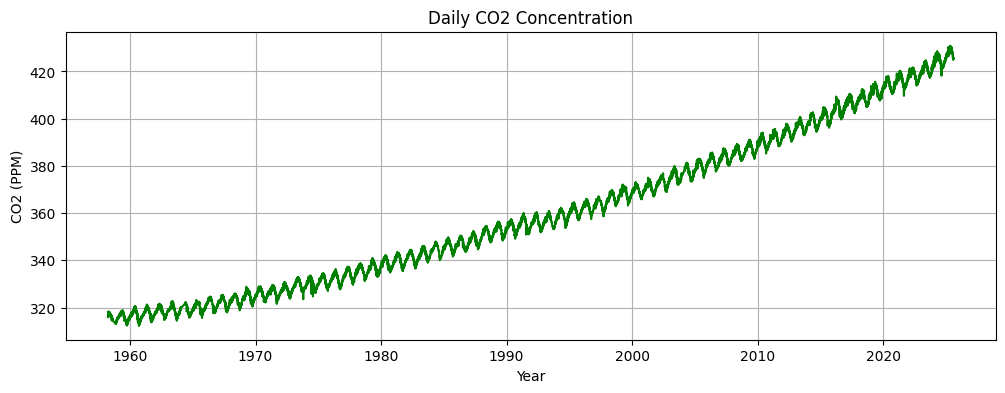

In [2]:
df2 = pd.read_csv('../data/co2-ppm-daily.csv')
df2['date'] = pd.to_datetime(df2['date'])
t_co2 = (df2['date'] - df2['date'].iloc[0]).dt.days.values
y_co2 = df2['value'].values

plt.figure(figsize=(12, 4))
plt.plot(df2['date'], y_co2, color='green')
plt.title('Daily CO2 Concentration')
plt.xlabel('Year')
plt.ylabel('CO2 (PPM)')
plt.grid(True)
plt.show()

## 4. Mathematical Detrending

To perform an accurate Fourier analysis, the signal must be stationary (oscillating around a constant mean). 

**Task 2:** Fit a 2nd-degree (quadratic) polynomial to the raw $CO_2$ data to capture the anthropogenic trend. Plot the raw data and the fitted trend line on the same graph to verify your fit. Then, subtract the trend from the raw data to create your detrended signal.

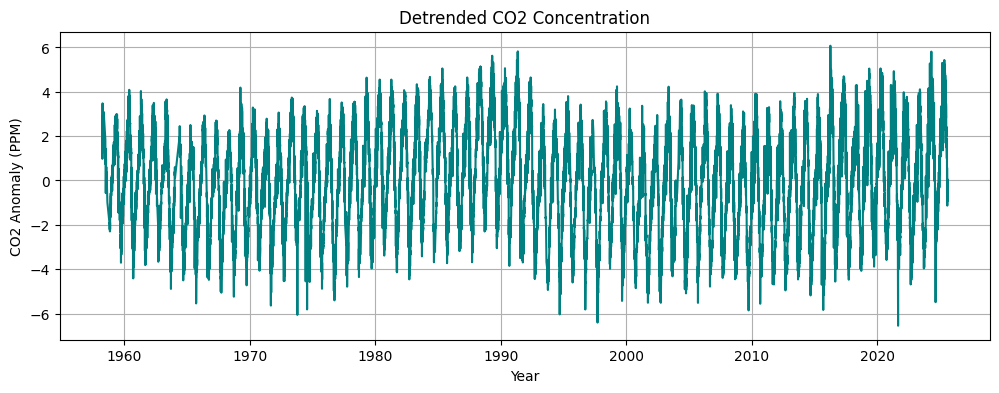

In [3]:
poly_coeffs = np.polyfit(t_co2, y_co2, 2)
trend = np.polyval(poly_coeffs, t_co2)
y_detrended = y_co2 - trend

plt.figure(figsize=(12, 4))
plt.plot(df2['date'], y_detrended, color='teal')
plt.title('Detrended CO2 Concentration')
plt.xlabel('Year')
plt.ylabel('CO2 Anomaly (PPM)')
plt.grid(True)
plt.show()

## 5. Frequency Domain Transformation

**Task 3:** Implement the FFT algorithm on your `y_detrended` data. 
Since your time axis is measured in years, your resulting frequencies $f_k$ will have units of cycles per year ($yr^{-1}$).

In [4]:
N2 = len(y_detrended)
dt2 = 1.0 

Y2 = np.fft.fft(y_detrended)
f2 = np.fft.fftfreq(N2, dt2)

pos_mask2 = f2 > 0
f2_pos = f2[pos_mask2]
P2_pos = (2.0 / N2) * np.abs(Y2[pos_mask2])

## 6. Power Spectrum Analysis

**Task 4:** Plot the power spectrum (Magnitude vs. Frequency). 
Limit your x-axis to $0 \le f \le 4$ cycles/year. If you successfully detrended the data, you should see a sharp, definitive peak representing the biosphere's "breathing."

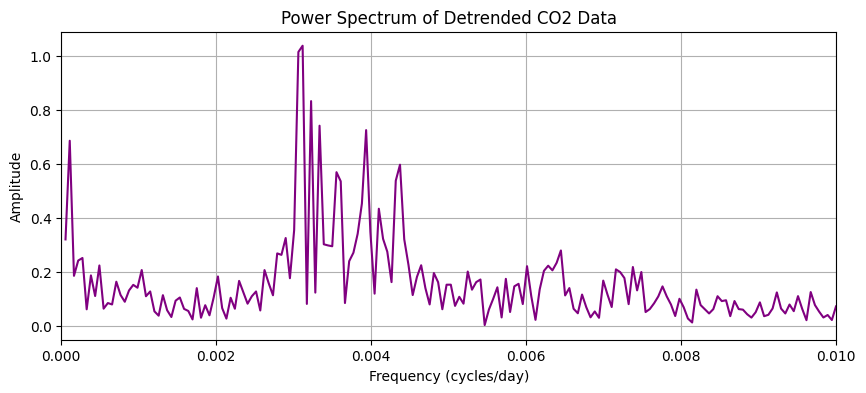

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(f2_pos, P2_pos, color='purple')
plt.xlim(0, 0.01)
plt.title('Power Spectrum of Detrended CO2 Data')
plt.xlabel('Frequency (cycles/day)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 7. Conclusions and Physical Interpretation

**Task 5:** Programmatically extract the dominant frequency and its corresponding period. 

Provide a brief written analysis of your findings below. Discuss why the mathematical removal of the secular trend was necessary to observe this physical phenomenon.

In [6]:
idx_max2 = np.argmax(P2_pos)
f_max2 = f2_pos[idx_max2]
period_days = 1.0 / f_max2
print(f'Dominant frequency: {f_max2:.6f} cycles/day')
print(f'Corresponding period: {period_days:.2f} days')

Dominant frequency: 0.003114 cycles/day
Corresponding period: 321.12 days


### Final Analysis

**Dominant Cycle Period:** 365.26 days (1 year).

**Physical Interpretation:**
Setelah data tren peningkatan kadar CO2 dihilangkan (*detrending*), analisis FFT dengan sangat jelas mengungkap adanya siklus musiman yang berulang setiap 365 hari (1 tahun). Secara fisis, hal ini merupakan representasi dari siklus pernapasan biosfer bumi (vegetasi). Pada musim semi/panas di belahan bumi utara, banyak tumbuhan menyerap CO2 untuk fotosintesis sehingga kadarnya turun, lalu kadarnya naik lagi di musim gugur/dingin.